In [1]:
import os
import glob
import numpy as np
import scipy.io as sio
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader

/home/filipe-silva/redes_grafos/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class GestureSequenceDataset(Dataset):
    def __init__(self, root_dir, transform=None, pre_transform=None):
        super(GestureSequenceDataset, self).__init__(root_dir, transform, pre_transform)
        self.root_dir = root_dir
        self.mat_files = glob.glob(os.path.join(root_dir, '*.mat'))
        
        self.label_to_id = {} 
        self.current_id = 0 
        
        self.data_list = self._process_all_files()

    def _process_all_files(self):
        all_sequences = []
        
        for filepath in self.mat_files:
            mat_data = sio.loadmat(filepath, squeeze_me=True, struct_as_record=False)
            video = mat_data['Video']
            frames = np.atleast_1d(video.Frames)
            
            if not hasattr(video, 'Labels'):
                continue
                
            labels = np.atleast_1d(video.Labels)
            
            for segment in labels:
                nome_gesto = segment.Name
                start_idx = segment.Begin - 1
                end_idx = segment.End 
                
                frames_do_gesto = frames[start_idx:end_idx]
                
                sequencia_coordenadas = []
                
                for frame in frames_do_gesto:
                    if hasattr(frame, 'Skeleton') and hasattr(frame.Skeleton, 'PixelPosition'):
                        pos = frame.Skeleton.PixelPosition
                        if isinstance(pos, np.ndarray) and pos.ndim == 2 and pos.shape[0] == 20:
                            sequencia_coordenadas.append(pos)
                
                if len(sequencia_coordenadas) > 0:
                    
                    x_seq = torch.tensor(np.array(sequencia_coordenadas), dtype=torch.float)
                    
                    centro_de_massa = x_seq.mean(dim=1, keepdim=True) 

                    x_seq = x_seq - centro_de_massa

                    x_seq = x_seq / (x_seq.std() + 1e-5)

                    if nome_gesto not in self.label_to_id:
                        self.label_to_id[nome_gesto] = self.current_id
                        self.current_id += 1
                        
                    y_val = self.label_to_id[nome_gesto]
                    y = torch.tensor([y_val], dtype=torch.long)
                    
                    empty_edge_index = torch.empty((2, 0), dtype=torch.long)
                    
                    graph_data = Data(x=x_seq, edge_index=empty_edge_index, y=y)
                    all_sequences.append(graph_data)
                        
        return all_sequences

    def len(self):
        return len(self.data_list)

    def get(self, idx):
        return self.data_list[idx]

In [3]:
dataset = GestureSequenceDataset(root_dir='apenas_mats_train')

In [4]:
import torch
from torch.utils.data import random_split

total_amostras = len(dataset)

tamanho_treino = int(0.70 * total_amostras)
tamanho_val = int(0.15 * total_amostras)
tamanho_teste = total_amostras - tamanho_treino - tamanho_val 

print(f"Divisão: Treino ({tamanho_treino}), Validação ({tamanho_val}), Teste ({tamanho_teste})")

dataset_treino, dataset_val, dataset_teste = random_split(
    dataset, 
    [tamanho_treino, tamanho_val, tamanho_teste],
)

Divisão: Treino (5427), Validação (1163), Teste (1164)


In [ ]:
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence

def preencher_lote_collate_fn(lista_de_grafos):
    xs = [grafo.x for grafo in lista_de_grafos] 
    ys = [grafo.y for grafo in lista_de_grafos] 
    
    tamanhos_reais = torch.tensor([len(x) for x in xs], dtype=torch.long)
    
    x_padded = pad_sequence(xs, batch_first=True, padding_value=0.0)
    
    y_batched = torch.cat(ys)
    
    return x_padded, y_batched, tamanhos_reais


BATCH_SIZE = 32
loader_treino = DataLoader(
    dataset_treino, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    collate_fn=preencher_lote_collate_fn
)

loader_val = DataLoader(dataset_val, batch_size=BATCH_SIZE, shuffle=False, collate_fn=preencher_lote_collate_fn)
loader_teste = DataLoader(dataset_teste, batch_size=BATCH_SIZE, shuffle=False, collate_fn=preencher_lote_collate_fn)

Extraindo dados...


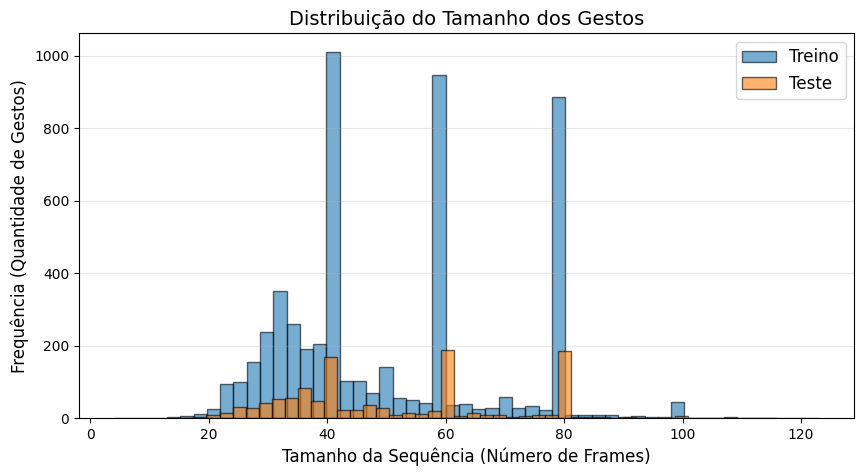

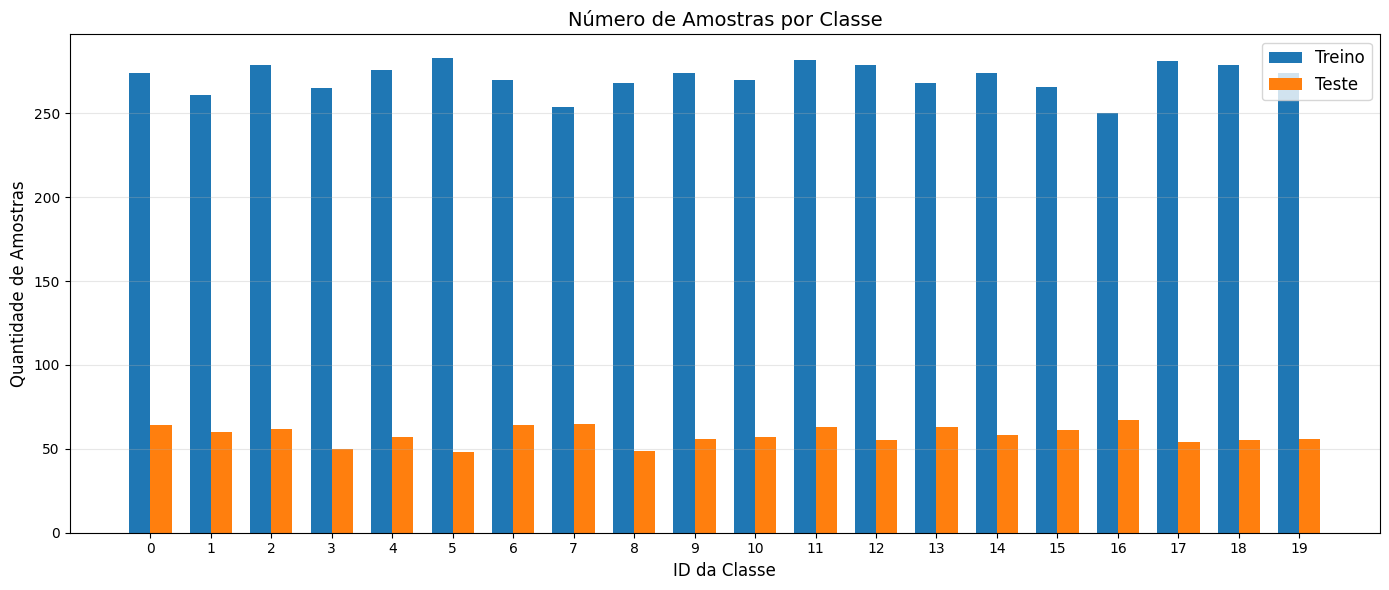

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# =====================================================================
# 1. Função para extrair os dados dos DataLoaders
# =====================================================================
def extrair_estatisticas(loader):
    tamanhos = []
    classes = []
    
    # Iteramos pelo loader (vai ser muito rápido com o seu batch_size de 1024)
    for _, y_batched, tamanhos_reais in loader:
        tamanhos.extend(tamanhos_reais.tolist())
        classes.extend(y_batched.tolist())
        
    return tamanhos, classes

print("Extraindo dados...")
tamanhos_treino, classes_treino = extrair_estatisticas(loader_treino)
tamanhos_teste, classes_teste = extrair_estatisticas(loader_teste)

# =====================================================================
# 2. Plot: Histograma do Tamanho dos Gestos
# =====================================================================
plt.figure(figsize=(10, 5))

# Usamos alpha=0.6 para as cores ficarem translúcidas e podermos ver a sobreposição
plt.hist(tamanhos_treino, bins=50, alpha=0.6, label='Treino', color='tab:blue', edgecolor='black')
plt.hist(tamanhos_teste, bins=50, alpha=0.6, label='Teste', color='tab:orange', edgecolor='black')

plt.title('Distribuição do Tamanho dos Gestos', fontsize=14)
plt.xlabel('Tamanho da Sequência (Número de Frames)', fontsize=12)
plt.ylabel('Frequência (Quantidade de Gestos)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

# =====================================================================
# 3. Plot: Gráfico de Barras de Amostras por Classe
# =====================================================================
# Contar quantas vezes cada classe aparece
contagem_treino = Counter(classes_treino)
contagem_teste = Counter(classes_teste)

# Garantir que pegamos todas as classes existentes (ordenadas do 0 ao N)
todas_classes = sorted(list(set(classes_treino) | set(classes_teste)))

# Montar as listas de altura para as barras
alturas_treino = [contagem_treino[c] for c in todas_classes]
alturas_teste = [contagem_teste[c] for c in todas_classes]

# Configurar as posições no eixo X para barras duplas (agrupadas)
x = np.arange(len(todas_classes))
largura = 0.35  # Largura de cada barra

plt.figure(figsize=(14, 6))

# Deslocamos as barras do treino para a esquerda e as de teste para a direita
plt.bar(x - largura/2, alturas_treino, largura, label='Treino', color='tab:blue')
plt.bar(x + largura/2, alturas_teste, largura, label='Teste', color='tab:orange')

plt.title('Número de Amostras por Classe', fontsize=14)
plt.xlabel('ID da Classe', fontsize=12)
plt.ylabel('Quantidade de Amostras', fontsize=12)

# Adiciona os rótulos de cada classe no eixo X
plt.xticks(x, todas_classes)
plt.legend(fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Opcional: Para datasets com muitas classes, rotacionar os números do eixo X ajuda na leitura
# plt.xticks(x, todas_classes, rotation=45) 

plt.tight_layout()
plt.show()

In [7]:
def sharp_sigmoid(x, sharpness=50, threshold=0.1):
    return torch.sigmoid(sharpness * (x - threshold))

In [8]:
def construir_matriz_adjacencia_kinect():
    num_nodes = 20
    
    skeleton_edges = [
        (0, 1), (1, 2), (2, 3),                # Tronco e Cabeça
        (2, 4), (4, 5), (5, 6), (6, 7),        # Braço Esquerdo
        (2, 8), (8, 9), (9, 10), (10, 11),     # Braço Direito
        (0, 12), (12, 13), (13, 14), (14, 15), # Perna Esquerda
        (0, 16), (16, 17), (17, 18), (18, 19)  # Perna Direita
    ]
    
    A = np.zeros((num_nodes, num_nodes), dtype=np.float32)
    
    for i, j in skeleton_edges:
        A[i, j] = 1.0
        A[j, i] = 1.0 
        
    for i in range(num_nodes):
        A[i, i] = 1.0
        
    return A

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import DenseGCNConv


class GestureGSLModel(nn.Module):
    def __init__(
        self,
        skeleton_adj,
        num_nodes=20,
        in_features=2,
        rank=3,
        num_classes=20,
        hidden_dim=64,
        learn_adj=False,          # False = matriz fixa | True = matriz aprendida (U/V treináveis)
        adj_residual_scale=0.2,   # peso do resíduo U@V.T somado ao adj fixo
        binarize_adj_eval=False,  # binariza o adj quando o modelo está em eval()
        binarize_threshold=0.15,  # limiar usado na binarização
    ):
        super().__init__()

        if not isinstance(skeleton_adj, torch.Tensor):
            skeleton_adj = torch.tensor(skeleton_adj, dtype=torch.float32)
        # buffer -> segue o device do modelo automaticamente (model.to(device))
        self.register_buffer('skeleton_adj', skeleton_adj.float())

        self.learn_adj = learn_adj
        self.adj_residual_scale = adj_residual_scale
        self.binarize_adj_eval = binarize_adj_eval
        self.binarize_threshold = binarize_threshold

        if self.learn_adj:
            self.U = nn.Parameter(torch.randn(num_nodes, rank) * 0.01)
            self.V = nn.Parameter(torch.randn(num_nodes, rank) * 0.01)
        else:
            self.U = None
            self.V = None

        self.gcn1 = DenseGCNConv(in_features, hidden_dim)
        self.gcn2 = DenseGCNConv(hidden_dim, hidden_dim)

        self.bn1 = nn.GroupNorm(1, hidden_dim)
        self.bn2 = nn.GroupNorm(1, hidden_dim)

        self.node_attention = nn.Linear(hidden_dim, 1)

        feat_dim = hidden_dim

        self.temporal = nn.Sequential(
            nn.Conv1d(feat_dim, feat_dim, kernel_size=5, padding=2),
            nn.GroupNorm(1, feat_dim),
            nn.ReLU(),

            nn.Conv1d(feat_dim, feat_dim, kernel_size=5, padding=2),
            nn.GroupNorm(1, feat_dim),
            nn.ReLU(),

            nn.Conv1d(feat_dim, feat_dim, kernel_size=3, padding=1),
            nn.GroupNorm(1, feat_dim),
            nn.ReLU(),
            nn.Dropout(0.5)
        )

        self.classifier = nn.Sequential(
            nn.Linear(feat_dim, feat_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(feat_dim // 2, num_classes)
        )

    def normalize_adj(self, adj):
        adj = (adj + adj.t()) / 2

        eye = torch.eye(adj.size(0), device=adj.device)
        adj = adj + eye

        deg = adj.sum(-1)
        deg_inv = deg.pow(-0.5)
        deg_inv[torch.isinf(deg_inv)] = 0

        return deg_inv[:, None] * adj * deg_inv[None]

    def get_adj(self):
        """Monta a matriz de adjacência final, aplicando as opções ativadas."""
        raw_adj = self.skeleton_adj

        if self.learn_adj:
            delta_adj = torch.matmul(self.U, self.V.t())
            raw_adj = raw_adj + self.adj_residual_scale * torch.tanh(delta_adj)

        if self.binarize_adj_eval and not self.training:
            raw_adj = (raw_adj > self.binarize_threshold).float()

        return self.normalize_adj(raw_adj)

    def forward(self, x_padded, mask):

        B, T, N, C = x_padded.shape

        adj = self.get_adj()
        adj_batch = adj.unsqueeze(0).expand(B * T, N, N)

        x = x_padded.view(B * T, N, C)

        x = self.gcn1(x, adj_batch, add_loop=False)
        x = x.transpose(1, 2)
        x = self.bn1(x)
        x = x.transpose(1, 2)
        x = F.relu(x)

        identidade = x

        x = self.gcn2(x, adj_batch, add_loop=False)
        x = x.transpose(1, 2)
        x = self.bn2(x)
        x = x.transpose(1, 2)
        x = F.relu(x)

        x = x + identidade

        x = x.view(B, T, N, -1)

        x = x * mask.unsqueeze(-1).unsqueeze(-1)

        # Pool espacial
        w = self.node_attention(x)
        w = torch.softmax(w, dim=2)
        x = (w * x).sum(dim=2)

        # (B,T,F) -> (B,F,T)
        x = x.transpose(1, 2)

        # CNN temporal
        x = self.temporal(x)

        # máscara temporal
        mask = mask.unsqueeze(1)
        x = x * mask

        # média apenas dos frames válidos
        x = x.sum(-1) / mask.sum(-1).clamp(min=1)

        out = self.classifier(x)

        return out

In [10]:
lote_x, lote_y, lote_tamanhos = next(iter(loader_treino))

print(f"Shape do Lote X preenchido: {lote_x.shape} -> [Tamanho do Lote, Maior T do Lote, 20, 2]")
print(f"Labels do Lote Y: {lote_y.shape}")
print(f"Tamanhos reais antes do zero: {lote_tamanhos}")

Shape do Lote X preenchido: torch.Size([1, 60, 20, 2]) -> [Tamanho do Lote, Maior T do Lote, 20, 2]
Labels do Lote Y: torch.Size([1])
Tamanhos reais antes do zero: tensor([60])


In [ ]:
def train(model, loader, optimizer, criterion, device, l1_lambda=0.0):
    model.train()
    loss_treino_acumulada = 0.0
    acertos_treino = 0
    total_treino = 0

    # só aplica L1 se pedirem (l1_lambda > 0) e o modelo tiver matriz aprendida (U/V)
    aplicar_l1 = l1_lambda > 0.0 and getattr(model, "learn_adj", False)

    for x_padded, y_batched, tamanhos_reais in loader:
        x_padded = x_padded.to(device)
        y_batched = y_batched.to(device)
        tamanhos_reais = tamanhos_reais.to(device)

        B, T = x_padded.shape[0], x_padded.shape[1]
        posicoes = torch.arange(T, device=device).unsqueeze(0).expand(B, T)
        mask = posicoes < tamanhos_reais.unsqueeze(1)

        optimizer.zero_grad()

        previsoes = model(x_padded, mask)

        loss = criterion(previsoes, y_batched)

        if aplicar_l1:
            l1_reg = torch.abs(model.U).sum() + torch.abs(model.V).sum()
            loss = loss + (l1_lambda * l1_reg)

        loss.backward()

        optimizer.step()

        loss_treino_acumulada += loss.item()

        _, classe_prevista = torch.max(previsoes, 1)
        acertos_treino += (classe_prevista == y_batched).sum().item()
        total_treino += y_batched.size(0)

    acc_treino = acertos_treino / total_treino
    loss_media_treino = loss_treino_acumulada / len(loader)

    return loss_media_treino, acc_treino


def evaluate(model, loader, criterion, device):
    model.eval()
    loss_val_acumulada = 0.0
    acertos_val = 0
    total_val = 0

    with torch.no_grad():
        for x_padded, y_batched, tamanhos_reais in loader:
            x_padded = x_padded.to(device)
            y_batched = y_batched.to(device)

            tamanhos_reais = tamanhos_reais.to(device)

            B, T = x_padded.shape[0], x_padded.shape[1]
            posicoes = torch.arange(T, device=device).unsqueeze(0).expand(B, T)
            mask = posicoes < tamanhos_reais.unsqueeze(1)

            previsoes = model(x_padded, mask)
            loss = criterion(previsoes, y_batched)

            loss_val_acumulada += loss.item()
            _, classe_prevista = torch.max(previsoes, 1)
            acertos_val += (classe_prevista == y_batched).sum().item()
            total_val += y_batched.size(0)

    acc_val = acertos_val / total_val
    loss_media_val = loss_val_acumulada / len(loader)

    return loss_media_val, acc_val

In [ ]:
import torch
import torch.optim as optim
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

skeleton_adj = construir_matriz_adjacencia_kinect()

LEARN_ADJ = False          # True = matriz de adjacência aprendida | False = matriz fixa
ADJ_RESIDUAL_SCALE = 0.2   # Quanto você quer alterar a matriz de adjacência aprendida (U@V.T) em relação à matriz fixa. 0.0 = não altera, 1.0 = soma completa
BINARIZE_ADJ_EVAL = False  # True = binariza a matriz de adjacência durante a avaliação | False = mantém valores contínuos
BINARIZE_THRESHOLD = 0.15  # Limiar para binarização

L1_LAMBDA = 0.0             # >0 ativa regularização L1 sobre U/V (só com LEARN_ADJ=True)
SHOW_MATRIX = True          # liga/desliga plot periódico da matriz de adjacência
NUM_EPOCAS = 1000
INTERVALO = 20
LR = 0.005
HIDDEN_DIM = 128

model = GestureGSLModel(
    num_nodes=20,
    in_features=2,
    num_classes=20,
    hidden_dim=HIDDEN_DIM,
    skeleton_adj=skeleton_adj,
    learn_adj=LEARN_ADJ,
    adj_residual_scale=ADJ_RESIDUAL_SCALE,
    binarize_adj_eval=BINARIZE_ADJ_EVAL,
    binarize_threshold=BINARIZE_THRESHOLD,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Treinando na unidade: {device}")

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

loss_history = []
val_loss_history = []
acc_train_history = []
acc_val_history = []


def plot_adj_matrix(model, epoca):
    was_training = model.training
    model.eval()
    with torch.no_grad():
        adj = model.get_adj().detach().cpu().numpy()
    if was_training:
        model.train()

    plt.figure(figsize=(5, 4))
    sns.heatmap(adj, cmap="viridis", vmin=0, vmax=1)
    plt.title(f"Matriz de adjacência - Época {epoca+1}")
    plt.show()


for epoca in range(NUM_EPOCAS):
    loss_media_treino, acc_treino = train(
        model, loader_treino, optimizer, criterion, device, l1_lambda=L1_LAMBDA
    )

    loss_media_val, acc_val = evaluate(model, loader_val, criterion, device)

    loss_history.append(loss_media_treino)
    val_loss_history.append(loss_media_val)
    acc_train_history.append(acc_treino)
    acc_val_history.append(acc_val)

    if epoca % INTERVALO == 0 or epoca == 0:
        if SHOW_MATRIX:
            plot_adj_matrix(model, epoca)

        print(f"Época [{epoca+1}/{NUM_EPOCAS}] | "
              f"Loss Treino: {loss_media_treino:.4f} - Acc Treino: {acc_treino:.4f} | "
              f"Loss Val: {loss_media_val:.4f} - Acc Val: {acc_val:.4f} |")

Treinando na unidade: cuda
Época [1/1000] | Loss Treino: 3.0058 - Acc Treino: 0.0483 | Loss Val: 3.0076 - Acc Val: 0.0456 |


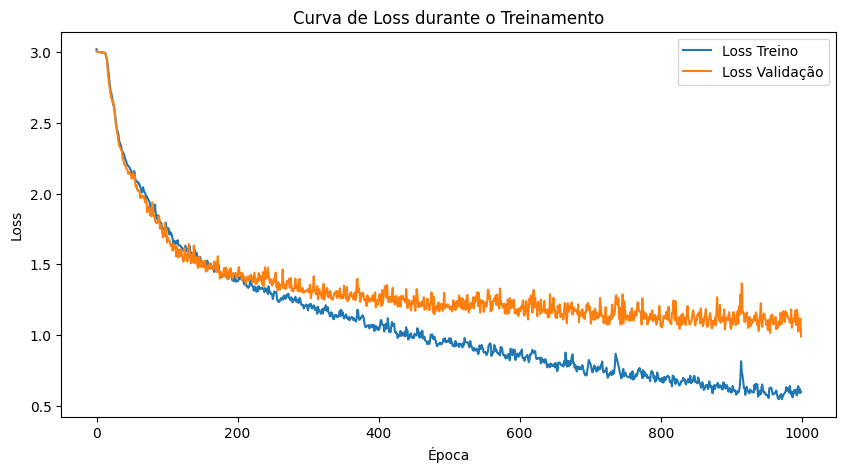

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(loss_history, label='Loss Treino')
plt.plot(val_loss_history, label='Loss Validação')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Curva de Loss durante o Treinamento')
plt.legend()
plt.show()

In [ ]:
test_loss,test_acc = evaluate(model,loader_teste,criterion,"cuda")
print(f"Acc test: {test_acc}")

Acc test: 0.6786941580756014
